# CONIFER — from a tree list to a stand report

### Compositional, design-aware small-area estimation of forest diameter distributions

You have a cruise. Some stands got plenty of plots, some got two. You need the **diameter
distribution** — stems per acre by DBH class — for every stand, including the thin ones, with
an interval you can defend to whoever is paying for the inventory.

This walkthrough goes end to end on a synthetic cruise shaped like a real one. Every number
and figure below is produced by the code above it.

## 1. The data you actually have

Three things, and only the first is mandatory:

| | what it is |
|---|---|
| **tree list** | one row per tallied tree — stand, plot, species, DBH |
| **stand metrics** | one row per stand — LiDAR / spectral / terrain predictors |
| **stand polygons** | optional; turns the results into maps |

The demo cruise is calibrated to the measured shape of the St. Joe (Idaho) inventory —
regeneration-dominated, a steep reverse-J, and heavily zero-inflated in the upper diameter
classes. That last property matters more than it looks: most stands genuinely tally **nothing**
in the larger classes, and an estimator that ignores this will quietly invent trees.

In [1]:
import numpy as np, pandas as pd, conifer
pd.set_option("display.width", 150)

trees, stand_metrics, stands, truth = conifer.demo.make_cruise(n_stands=160, seed=11)
print("CONIFER", conifer.__version__)
trees.head(6)

CONIFER 0.2.5


,STAND,PLOT,SPECIES,DBH_IN
0,S0001,P1,Douglas-fir,2.1
1,S0001,P1,lodgepole pine,1.7
2,S0001,P1,Douglas-fir,3.3
3,S0001,P2,grand fir,1.2
4,S0001,P3,western redcedar,3.1
5,S0001,P3,grand fir,1.5


In [2]:
stand_metrics.head(4)

,STAND,STAND_TYPE,HAG_mean,HAG_p95,HAG_sd,CanopyCover,CanopyReliefRatio,DensityAbove4,VCI,FoliageHeightDiversity,slope,elev
0,S0001,young managed,8.30,21.35,3.80,0.281,0.461,0.0436,1.047,0.980,34.0,758.0
1,S0002,mature mixed conifer,14.78,39.55,3.20,0.447,0.445,0.0723,1.079,0.882,27.7,1338.0
2,S0003,regenerating,5.35,12.51,2.82,0.307,0.321,0.0346,0.885,0.765,6.3,1180.0
3,S0004,mature mixed conifer,10.09,27.55,3.18,0.488,0.510,0.0500,1.014,1.116,19.9,934.0


## 2. One call to get it in

`from_treelist` bins DBH into classes, derives the effective area, and — importantly — wires
the **correct sampling covariance for your plot design**. It also carries your stand
identifiers through every table, figure and export, so a mis-sorted input cannot silently
corrupt the estimate.

In [3]:
inv = conifer.from_treelist(
    trees,
    stand_col="STAND", plot_col="PLOT", dbh_col="DBH_IN",
    plot_area=0.2,                      # fixed-area cruise; use baf=20 for a prism cruise
    aux=stand_metrics, aux_stand_col="STAND",
    group_col="STAND_TYPE",             # calibrate within stand type
)
inv.describe()

,value
,
Stands (small areas),160
DBH classes,6 (1-5 in ... 21-25 in)
Covariates,"10 (HAG_mean, HAG_p95, HAG_sd, CanopyCover...)"
Plot design,fixed-area plots
Total trees tallied,"18,650"
Plots per stand (median),20
Stands with 2+ plots,160
Sampled area,774.60 acres
Sampling covariance,"design-based, from plot replicates"


### Check the data before you trust the answer

`validate()` runs automatically and reports problems in language you can act on.

In [4]:
inv.issue_table()

,level,code,message,suggested fix
0,note,dropped_out_of_range,Dropped 2 tree(s) whose DBH fell outside 1-25 in.,Widen `breaks` if those trees should be included.


## 3. Fit

One call. The estimator blends each stand's own plot data with what comparable stands and the
covariates support — leaning on the model exactly as far as that stand's data is thin.

In [5]:
est = inv.fit()
print("estimated", est.s_hat_.shape[0], "stands x", est.s_hat_.shape[1], "DBH classes")

estimated 160 stands x 6 DBH classes


### How much of this came from my cruise?

The first question any forester asks. `data_gain` answers it honestly: it is the model's own
shrinkage weight, γ = Su/(Su+Dᵢ), which rises toward 1 as a stand accumulates plots.

In [6]:
from conifer.report import data_gain
g = data_gain(est)
print("share of the estimate from the stand's own plots:")
print("  min %.0f%%   median %.0f%%   max %.0f%%" % (100*g.min(), 100*np.median(g), 100*g.max()))
print("  correlation with plot count: %.2f" % np.corrcoef(g, inv.n_plots)[0, 1])

share of the estimate from the stand's own plots:
  min 85%   median 99%   max 100%
  correlation with plot count: 0.48


## 4. Intervals that survive contact with the tail

This is the part that is easy to get wrong, so it is worth being explicit.

Conformal prediction needs a calibration set where the truth is known. **A real inventory never
has one.** The tempting shortcut — calibrating against the direct estimate of the same plots
used to fit — is invalid, because the estimate is a *shrinkage of* that target, so the residual
is mechanically smaller than the real error. Measured against a known truth it under-covers at
68% for a nominal 90% set.

`calibrated_intervals` does three things instead, and treats tallied and untallied classes as
the different problems they are:

1. **Classes the stand tallied** get a Gaussian built on the parametric bootstrap MSE, inflated
   per class by a factor calibrated from *your* data by splitting each stand's plots.
2. **Classes with no tally** get a stratified bound plus a physical zero floor. No Gaussian
   works at the zero boundary whatever its standard deviation.
3. The whole thing is deliberately calibrated to sit slightly **wide** of the stated level. A
   factor tuned to hit nominal exactly on one forest does not transfer to the next.

In [7]:
from conifer.calibration import calibrated_intervals

lo, hi = calibrated_intervals(est, alpha=0.10, B=10, reps=2, seed=1)
rep = est.interval_report_
print("per-class inflation, calibrated from this cruise:", np.round(rep["inflation_per_class"], 2))
print()
print(rep.summary)

per-class inflation, calibrated from this cruise: [1.94 1.73 1.67 2.67 1.38 1.96]

90% intervals: a bootstrap-MSE Gaussian on the classes this stand actually tallied, inflated per class by [1.94, 1.73, 1.67, 2.67, 1.38, 1.96] as calibrated from your own plot data; a stratified bound and a zero floor on classes with no tally. Calibrated to sit slightly wide of the stated level rather than exactly on it, because a factor tuned to hit nominal on one forest does not transfer to the next.


### Does it hold up?

The demo kept the truth, so we can check. A real inventory cannot do this — which is why the
calibration above never uses it.

In [8]:
T = truth.set_index("STAND").reindex(inv.stand_ids).to_numpy(float)
pop = inv.counts > 0
inside = (T >= lo) & (T <= hi)
print("nominal 90% | measured coverage")
print("  overall                %.3f" % inside.mean())
print("  classes with a tally   %.3f" % inside[pop].mean())
print("  classes with no tally  %.3f" % inside[~pop].mean())

nominal 90% | measured coverage
  overall                0.955
  classes with a tally   0.982
  classes with no tally  0.932


Slightly above nominal on every stratum — the right direction to be wrong for a tool
someone makes decisions with.

## 5. The tables you hand someone

In [9]:
from conifer import report as R
R.class_summary(est)

,direct estimate (TPA),mean TPA,low,high,share of stems (%),stands carrying this class
DBH class,,,,,,
1-5 in,19.56,19.49,15.93,23.05,79.12,155
5-9 in,3.51,3.55,2.35,4.76,14.42,92
9-13 in,0.54,0.57,0.31,0.85,2.31,34
13-17 in,0.78,0.76,0.51,1.04,3.07,20
17-21 in,0.17,0.17,0.11,0.27,0.70,5
21-25 in,0.12,0.09,0.05,0.17,0.38,4


In [10]:
R.summary_table(est).head(6)

,plots,sampled acres,total TPA,basal area (ft²/ac),QMD (in),total TPA — low,total TPA — high,interval width (TPA),"interval width, classes with stems (%)",% from own plots,% from similar stands
stand,,,,,,,,,,,
S0001,45,9.0,17.8,0.9,3.1,15.3,20.3,5.0,41.5,99.6,0.4
S0002,15,3.0,30.5,5.0,5.5,21.0,40.1,19.0,70.4,97.9,2.1
S0003,20,4.0,41.5,2.1,3.1,35.8,47.2,11.4,52.3,99.2,0.8
S0004,16,3.2,15.3,2.5,5.4,10.4,20.3,9.9,90.2,97.5,2.5
S0005,18,3.6,16.4,0.9,3.2,12.8,20.1,7.3,63.1,98.9,1.1
S0006,21,4.2,19.6,3.7,5.9,13.8,25.4,11.6,75.6,97.9,2.1


Note the two width columns. The relative figure is computed on the classes a stand
actually tallied; for classes with no tally the interval runs from zero up to a fraction of a
stem per acre, which is small in absolute terms but enormous as a percentage because the
estimate it is measured against is near zero. Read those in TPA, not percent.

In [11]:
R.stand_table(est).head(4)

DBH class 1-5 in             5-9 in            9-13 in           13-17 in           17-21 in           21-25 in          
             TPA   low  high    TPA  low  high     TPA  low high      TPA  low high      TPA  low high      TPA  low high
stand                                                                                                                    
S0001       17.6  15.1  20.0    0.2  0.1   0.2     0.0  0.0  0.0      0.0  0.0  0.0      0.0  0.0  0.0      0.0  0.0  0.0
S0002       16.9  12.3  21.5   12.3  8.0  16.5     1.4  0.8  1.9      0.0  0.0  0.0      0.0  0.0  0.0      0.0  0.0  0.0
S0003       41.1  35.6  46.6    0.4  0.2   0.5     0.0  0.0  0.0      0.0  0.0  0.0      0.0  0.0  0.0      0.0  0.0  0.0
S0004       11.8   8.8  14.9    2.0  0.8   3.2     0.8  0.4  1.1      0.7  0.3  1.0      0.0  0.0  0.0      0.0  0.0  0.0

## 6. Field-only against CONIFER

The argument for a model-based estimate makes itself, or it does not. Stands far off the 1:1
line are where the model changed the answer — and they should be the ones with few plots.

findfont: Failed to find font weight semibold, now using 700.


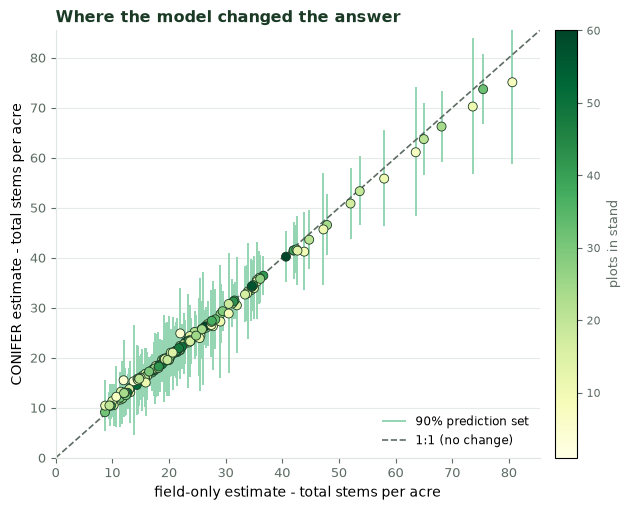

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
from conifer import plots as P

fig, ax = plt.subplots(figsize=(6.4, 5.2))
P.plot_comparison(est, ax=ax)
plt.tight_layout(); plt.show()

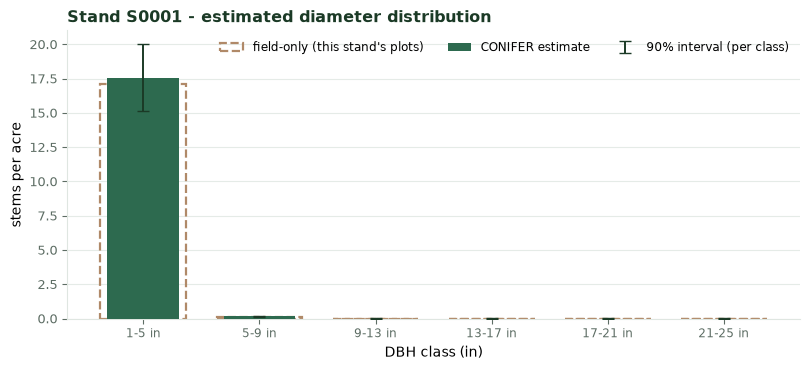

In [13]:
fig, ax = plt.subplots(figsize=(8.2, 3.8))
P.plot_distribution(est, stand=0, ax=ax)
plt.tight_layout(); plt.show()

## 7. In plain words

`narrative()` reads the result back in sentences. Every figure in it is taken from the fit —
nothing is generated, so nothing can be a hallucinated number.

In [14]:
for para in R.narrative(est):
    print(para.replace("**", ""), "\n")

Estimated diameter distributions for 160 stands, across 6 DBH classes (1-5 in through 21-25 in). The fit rests on 18,650 tallied stems over 775 sampled acres, a median of 20 plots per stand. 

Across everything, a typical stand carries 25 TPA with 4 ft²/ac of basal area, at a quadratic mean diameter of 5.2 in. That last figure spans 3.0 to 18.7 in across the property, so the average hides a good deal. The bulk of the stems sit in the 1-5 in class — 19 TPA, roughly 79% of the total. 

On average 98% of a stand's estimate comes from its own plots, the rest from stands with comparable structure. That weight is the model's shrinkage factor, not a setting anyone picked, and here it spans 85% to 100%. The stands leaning hardest on their neighbours are S0059, S0147, S0008. If something in this report looks wrong, start with those. 

Each DBH class carries its own 90% prediction interval, calibrated per class. On classes where the cruise found stems, those intervals run to about ±34% of the es

## 8. Out the door

```python
conifer.report.to_excel(est, "results.xlsx")          # multi-sheet workbook
conifer.report.to_html(est, "stand_report.html")      # printable stand report

# and back into your GIS, with legal field names
gdf = conifer.read_stands("stands.gpkg", stand_col="STAND")
conifer.attach_estimates(gdf, R.summary_table(est), stand_col="STAND").to_file("out.gpkg", driver="GPKG")
```

Or skip the code entirely:

```bash
pip install "conifer-sae[app]"
streamlit run apps/forester/app.py
```

---

### What this demo does and does not show

It exercises the **workflow** on data shaped like a real cruise, and it checks that the
intervals hold up. It is **not** evidence of accuracy: at ~20 plots per stand this is the
data-rich regime, where a Fay–Herriot estimator is supposed to converge to the direct estimate
rather than beat it, and the synthetic covariates carry less signal than real LiDAR. CONIFER's
accuracy claim rests on the St. Joe (Idaho) and Arkansas studies against real cruises, where
the covariates are real and the merchantable tallies are genuinely thin.